# LibriSpeech 三种 CTC 模型训练与测试分析

本 Notebook 对 **BiLSTM-CTC、Transformer-CTC、Mamba2-CTC** 的训练过程和最终测试结果进行统一分析。

分析内容包括：

1. 实验配置与训练效率；
2. Train/Dev loss 收敛过程；
3. Dev WER/CER 变化；
4. 学习率调度和单轮训练时间；
5. Dev/Test 最终指标对比；
6. 测试集逐句错误、错误类型和语句长度影响；
7. 典型识别样例与可直接用于报告的结论。

> 所有比较均使用同一 LibriSpeech 字符词表、CTC 贪心解码和同一评估代码，不使用外部语言模型。

In [1]:
from pathlib import Path
import json
import os
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 4)

# 在项目根目录启动 Notebook 时自动使用当前目录；保留绝对路径作为兜底。
current_dir = Path.cwd()
fallback_root = Path(r"D:\1workpath\library_speech_code")
PROJECT_ROOT = current_dir if (current_dir / "runs").exists() else fallback_root
RUNS_ROOT = PROJECT_ROOT / "runs"
LOG_ROOT = PROJECT_ROOT / "log"
OUTPUT_DIR = Path(
    os.environ.get("LIBRISPEECH_ANALYSIS_OUTPUT", PROJECT_ROOT / "analysis_outputs")
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_RUNS = {
    "BiLSTM-CTC": RUNS_ROOT / "bilstm_ctc_100h" / "job_60650500_seed7",
    "Transformer-CTC": RUNS_ROOT / "transformer_ctc_100h" / "job_60670539_seed7",
    "Mamba2-CTC": RUNS_ROOT / "mamba2_ctc_100h" / "job_60887271_seed7",
}

COLORS = {
    "BiLSTM-CTC": "#4C78A8",
    "Transformer-CTC": "#F58518",
    "Mamba2-CTC": "#54A24B",
}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.frameon": False,
        "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
        "axes.unicode_minus": False,
    }
)


def save_and_show(fig, filename):
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, bbox_inches="tight")
    plt.show()


missing = [str(path) for path in MODEL_RUNS.values() if not path.exists()]
if missing:
    raise FileNotFoundError("以下运行目录不存在：\n" + "\n".join(missing))

print(f"项目根目录: {PROJECT_ROOT}")
print(f"图表与汇总表输出目录: {OUTPUT_DIR}")

项目根目录: d:\1workpath\library_speech_code
图表与汇总表输出目录: d:\1workpath\library_speech_code\analysis_outputs


## 1. 加载并校验实验记录

每个模型均从自己的运行目录读取：

- `history.csv`：逐轮训练指标；
- `evaluation/summary.json`：Dev/Test 汇总指标；
- `evaluation/test-clean_predictions.tsv`：测试集逐句识别结果；
- `config.resolved.yaml`：实际生效的实验配置；
- `environment.json`：训练环境信息；
- `log/job_<id>_seed7.log`：参数量等训练日志。

In [2]:
REQUIRED_HISTORY_COLUMNS = {
    "epoch",
    "train_loss",
    "dev_loss",
    "dev_wer",
    "dev_cer",
    "learning_rate",
    "seconds",
}


def read_parameter_count(run_dir):
    log_path = LOG_ROOT / f"{run_dir.name}.log"
    if not log_path.exists():
        return np.nan
    text = log_path.read_text(encoding="utf-8", errors="replace")
    match = re.search(r"Model parameters:\s*([\d,]+)", text)
    return int(match.group(1).replace(",", "")) if match else np.nan


histories = {}
evaluations = {}
configs = {}
environments = {}
predictions = {}

for model, run_dir in MODEL_RUNS.items():
    history = pd.read_csv(run_dir / "history.csv")
    missing_columns = REQUIRED_HISTORY_COLUMNS.difference(history.columns)
    if missing_columns:
        raise ValueError(f"{model} history.csv 缺少字段: {sorted(missing_columns)}")

    with (run_dir / "evaluation" / "summary.json").open(encoding="utf-8") as handle:
        evaluation = json.load(handle)
    with (run_dir / "config.resolved.yaml").open(encoding="utf-8") as handle:
        config = yaml.safe_load(handle)
    with (run_dir / "environment.json").open(encoding="utf-8") as handle:
        environment = json.load(handle)

    prediction = pd.read_csv(
        run_dir / "evaluation" / "test-clean_predictions.tsv",
        sep="	",
        keep_default_na=False,
    )
    expected_prediction_columns = {"utterance_id", "reference", "hypothesis"}
    if not expected_prediction_columns.issubset(prediction.columns):
        raise ValueError(f"{model} 的预测文件字段不完整")

    histories[model] = history
    evaluations[model] = evaluation
    configs[model] = config
    environments[model] = environment
    predictions[model] = prediction

integrity_rows = []
for model in MODEL_RUNS:
    integrity_rows.append(
        {
            "Model": model,
            "Epoch records": len(histories[model]),
            "Test utterances": len(predictions[model]),
            "Checkpoint epoch": evaluations[model]["test-clean"]["checkpoint_epoch"],
            "GPU": environments[model].get("gpu"),
            "Parameters": read_parameter_count(MODEL_RUNS[model]),
        }
    )

integrity_df = pd.DataFrame(integrity_rows).set_index("Model")
display(integrity_df.style.format({"Parameters": "{:,.0f}"}))

,Epoch records,Test utterances,Checkpoint epoch,GPU,Parameters
Model,,,,,
BiLSTM-CTC,41,2620,41,NVIDIA H100 80GB HBM3,"4,092,701"
Transformer-CTC,70,2620,70,NVIDIA H100 80GB HBM3,"4,123,165"
Mamba2-CTC,35,2620,33,NVIDIA H100 80GB HBM3,"4,497,165"


## 2. 模型配置与训练效率

训练时间取 `history.csv` 中各轮 `seconds` 之和。最佳轮次按 Dev WER 最低点确定，并与实际保存的 `best.pt` 轮次交叉核对。

In [3]:
def compact_model_config(model_config):
    return ", ".join(
        f"{key}={value}" for key, value in model_config.items() if key != "name"
    )


training_rows = []
for model, history in histories.items():
    best_row = history.loc[history["dev_wer"].idxmin()]
    checkpoint_epoch = evaluations[model]["test-clean"]["checkpoint_epoch"]
    training_rows.append(
        {
            "Model": model,
            "Parameters (M)": read_parameter_count(MODEL_RUNS[model]) / 1e6,
            "Epochs run": int(history["epoch"].max()),
            "Best epoch": int(best_row["epoch"]),
            "Checkpoint epoch": int(checkpoint_epoch),
            "Best Dev WER (%)": 100 * best_row["dev_wer"],
            "Best Dev CER (%)": 100 * best_row["dev_cer"],
            "Total train time (h)": history["seconds"].sum() / 3600,
            "Mean epoch time (s)": history["seconds"].mean(),
            "Final train loss": history.iloc[-1]["train_loss"],
            "Final dev loss": history.iloc[-1]["dev_loss"],
            "Model configuration": compact_model_config(configs[model]["model"]),
        }
    )

training_df = pd.DataFrame(training_rows).set_index("Model")
training_df.to_csv(OUTPUT_DIR / "training_comparison.csv")
display(
    training_df.style.format(
        {
            "Parameters (M)": "{:.3f}",
            "Best Dev WER (%)": "{:.2f}",
            "Best Dev CER (%)": "{:.2f}",
            "Total train time (h)": "{:.2f}",
            "Mean epoch time (s)": "{:.1f}",
            "Final train loss": "{:.4f}",
            "Final dev loss": "{:.4f}",
        }
    )
)

,Parameters (M),Epochs run,Best epoch,Checkpoint epoch,Best Dev WER (%),Best Dev CER (%),Total train time (h),Mean epoch time (s),Final train loss,Final dev loss,Model configuration
Model,,,,,,,,,,,
BiLSTM-CTC,4.093,41,41,41,32.31,11.84,2.26,198.8,0.1774,0.5426,"conv_channels=128, hidden_size=256, lstm_layers=3, dropout=0.2"
Transformer-CTC,4.123,70,70,70,36.42,12.23,1.69,86.7,0.3067,0.5908,"conv_channels=128, d_model=256, encoder_layers=5, attention_heads=4, feedforward_size=1024, dropout=0.1"
Mamba2-CTC,4.497,35,33,33,35.06,12.30,1.65,169.5,0.2290,0.5876,"conv_channels=128, d_model=256, mamba_layers=10, d_state=64, d_conv=4, expand=2, headdim=64, chunk_size=256, dropout=0.1"


## 3. Loss 收敛曲线

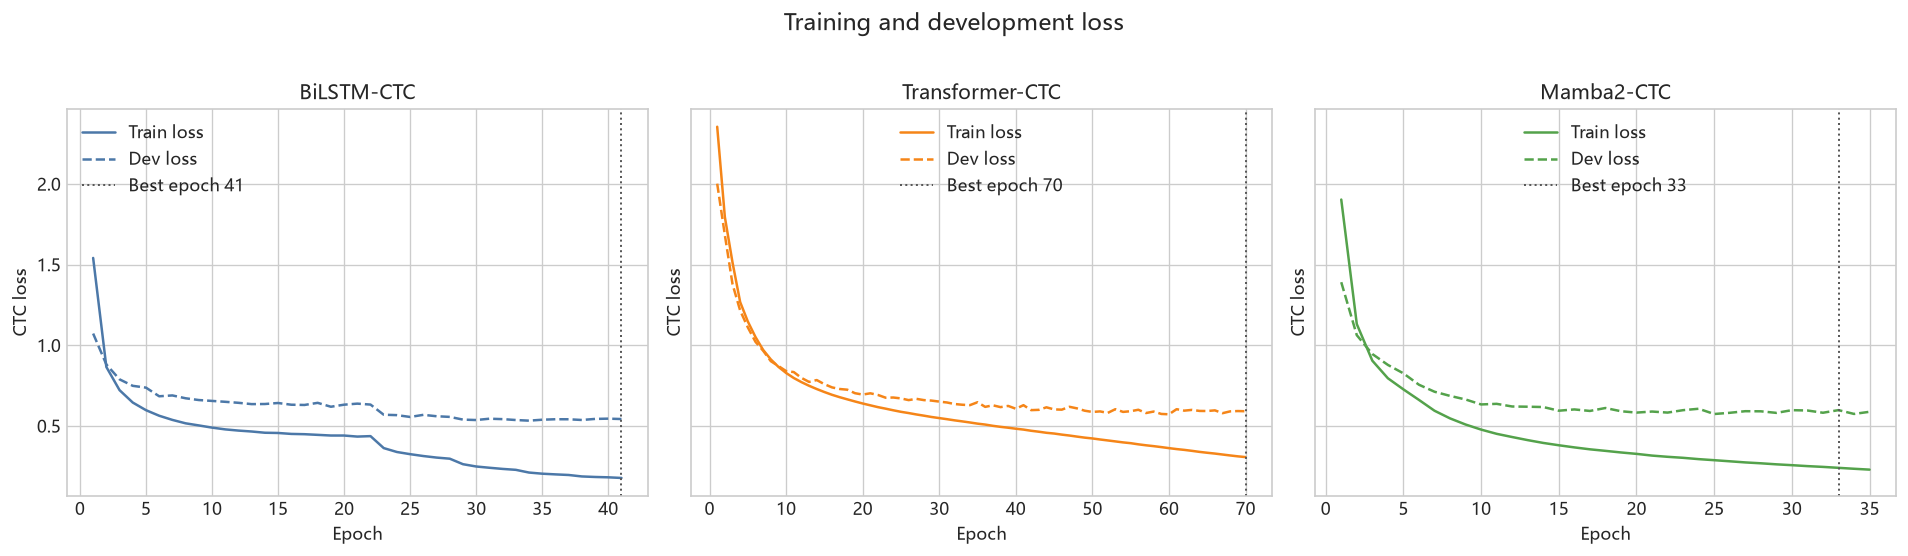

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, (model, history) in zip(axes, histories.items()):
    best_epoch = int(history.loc[history["dev_wer"].idxmin(), "epoch"])
    ax.plot(history["epoch"], history["train_loss"], label="Train loss", color=COLORS[model])
    ax.plot(
        history["epoch"],
        history["dev_loss"],
        label="Dev loss",
        color=COLORS[model],
        linestyle="--",
    )
    ax.axvline(best_epoch, color="0.35", linestyle=":", linewidth=1.2, label=f"Best epoch {best_epoch}")
    ax.set_title(model)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("CTC loss")
    ax.legend()

fig.suptitle("Training and development loss", y=1.02, fontsize=14)
save_and_show(fig, "training_loss_curves.png")

## 4. Dev WER 与 CER 收敛过程

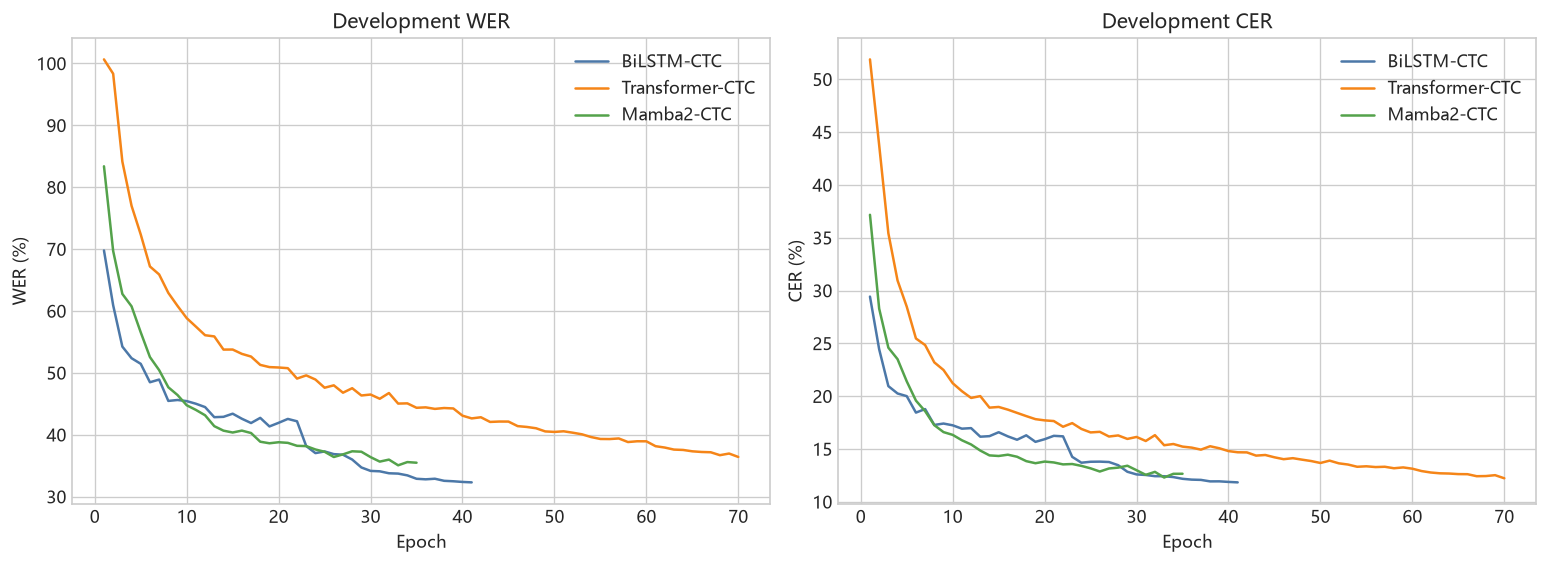

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for model, history in histories.items():
    axes[0].plot(history["epoch"], 100 * history["dev_wer"], label=model, color=COLORS[model])
    axes[1].plot(history["epoch"], 100 * history["dev_cer"], label=model, color=COLORS[model])

axes[0].set(title="Development WER", xlabel="Epoch", ylabel="WER (%)")
axes[1].set(title="Development CER", xlabel="Epoch", ylabel="CER (%)")
for ax in axes:
    ax.legend()

save_and_show(fig, "dev_error_curves.png")

## 5. 学习率调度与单轮训练时间

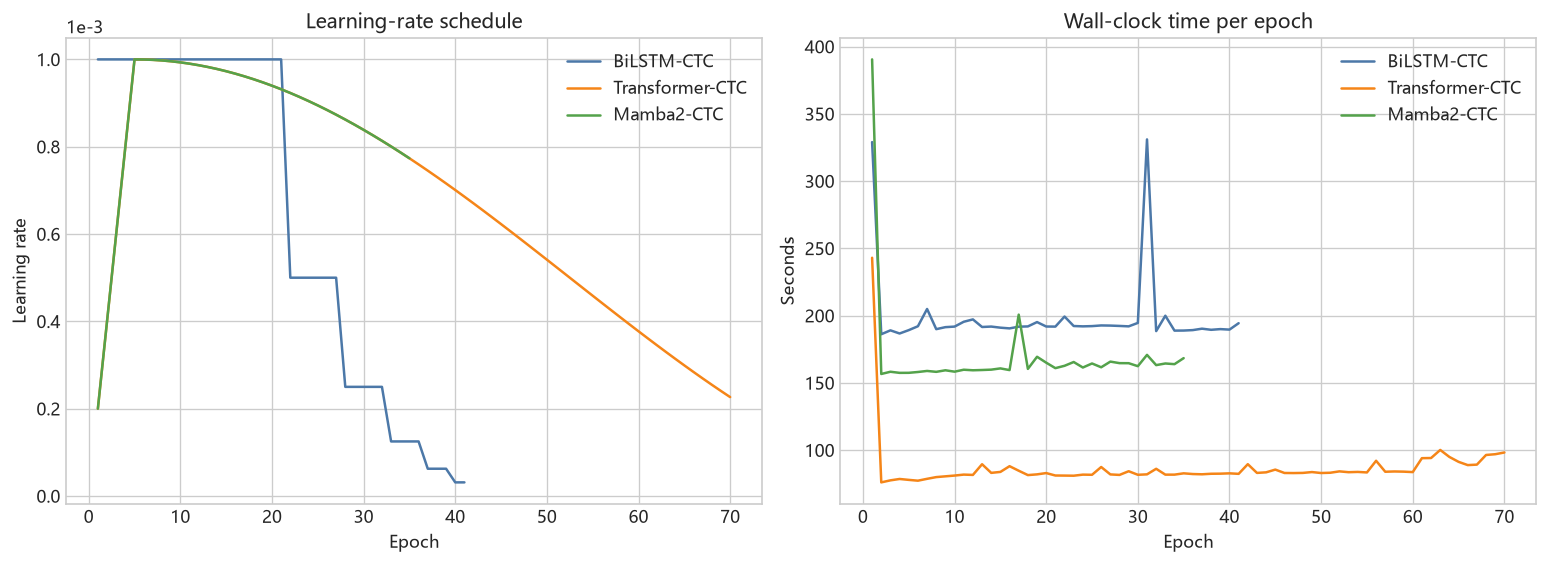

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for model, history in histories.items():
    axes[0].plot(history["epoch"], history["learning_rate"], label=model, color=COLORS[model])
    axes[1].plot(history["epoch"], history["seconds"], label=model, color=COLORS[model])

axes[0].set(title="Learning-rate schedule", xlabel="Epoch", ylabel="Learning rate")
axes[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axes[1].set(title="Wall-clock time per epoch", xlabel="Epoch", ylabel="Seconds")
for ax in axes:
    ax.legend()

save_and_show(fig, "optimization_diagnostics.png")

## 6. Dev/Test 最终结果

最终比较使用训练过程中由 Dev WER 选择出的 `best.pt`。`test-clean` 只用于最终报告，不参与模型选择。

In [7]:
evaluation_rows = []
for model, summary in evaluations.items():
    dev = summary["dev-clean"]
    test = summary["test-clean"]
    evaluation_rows.append(
        {
            "Model": model,
            "Checkpoint epoch": test["checkpoint_epoch"],
            "Dev loss": dev["loss"],
            "Dev WER (%)": 100 * dev["wer"],
            "Dev CER (%)": 100 * dev["cer"],
            "Test loss": test["loss"],
            "Test WER (%)": 100 * test["wer"],
            "Test CER (%)": 100 * test["cer"],
            "Test utterances": test["num_utterances"],
            "Test-Dev WER gap (pp)": 100 * (test["wer"] - dev["wer"]),
        }
    )

evaluation_df = pd.DataFrame(evaluation_rows).set_index("Model")
evaluation_df.to_csv(OUTPUT_DIR / "evaluation_comparison.csv")
display(
    evaluation_df.style.format(
        {
            "Dev loss": "{:.4f}",
            "Dev WER (%)": "{:.2f}",
            "Dev CER (%)": "{:.2f}",
            "Test loss": "{:.4f}",
            "Test WER (%)": "{:.2f}",
            "Test CER (%)": "{:.2f}",
            "Test-Dev WER gap (pp)": "{:+.2f}",
        }
    ).highlight_min(subset=["Test WER (%)", "Test CER (%)"], color="#d9ead3")
)

,Checkpoint epoch,Dev loss,Dev WER (%),Dev CER (%),Test loss,Test WER (%),Test CER (%),Test utterances,Test-Dev WER gap (pp)
Model,,,,,,,,,
BiLSTM-CTC,41,0.5426,32.32,11.84,0.5416,31.77,11.63,2620,-0.55
Transformer-CTC,70,0.5910,36.45,12.23,0.5903,36.29,12.30,2620,-0.15
Mamba2-CTC,33,0.5978,35.06,12.30,0.5920,34.52,12.08,2620,-0.54


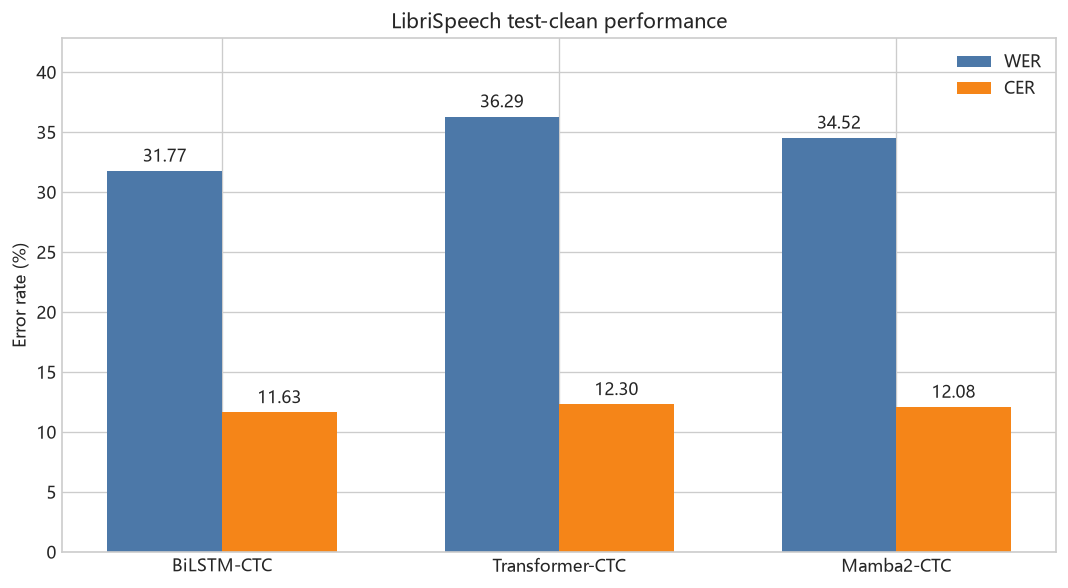

In [8]:
plot_df = evaluation_df[["Test WER (%)", "Test CER (%)"]]
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(plot_df))
width = 0.34
bars_wer = ax.bar(x - width / 2, plot_df["Test WER (%)"], width, label="WER", color="#4C78A8")
bars_cer = ax.bar(x + width / 2, plot_df["Test CER (%)"], width, label="CER", color="#F58518")

ax.set_xticks(x, plot_df.index)
ax.set_ylabel("Error rate (%)")
ax.set_title("LibriSpeech test-clean performance")
ax.legend()
ax.bar_label(bars_wer, fmt="%.2f", padding=3)
ax.bar_label(bars_cer, fmt="%.2f", padding=3)
ax.set_ylim(0, max(plot_df.max()) * 1.18)

save_and_show(fig, "test_metrics.png")

## 7. 训练成本与测试性能权衡

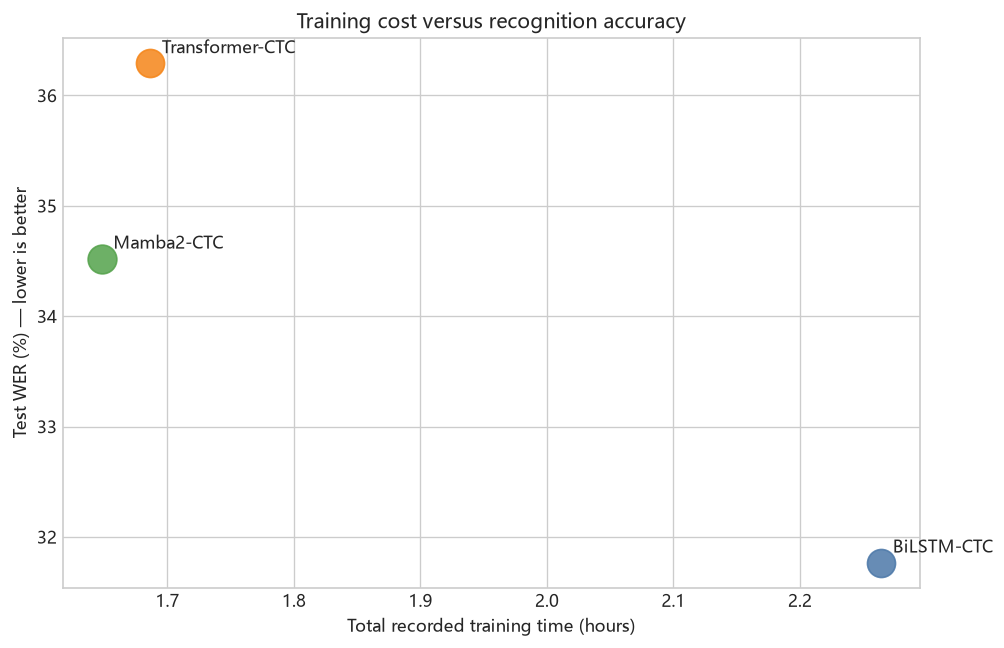

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))

for model in MODEL_RUNS:
    x_value = training_df.loc[model, "Total train time (h)"]
    y_value = evaluation_df.loc[model, "Test WER (%)"]
    size = 140 + training_df.loc[model, "Parameters (M)"] * 35
    ax.scatter(x_value, y_value, s=size, color=COLORS[model], alpha=0.85)
    ax.annotate(model, (x_value, y_value), xytext=(7, 6), textcoords="offset points")

ax.set_xlabel("Total recorded training time (hours)")
ax.set_ylabel("Test WER (%) — lower is better")
ax.set_title("Training cost versus recognition accuracy")

save_and_show(fig, "efficiency_tradeoff.png")

## 8. 测试集逐句错误分析

下面从逐句预测中重新计算单词级替换（S）、删除（D）和插入（I），并验证重新计算的 WER 与 `summary.json` 一致。

In [10]:
def word_edit_counts(reference, hypothesis):
    ref = reference.split()
    hyp = hypothesis.split()
    n, m = len(ref), len(hyp)
    cost = np.zeros((n + 1, m + 1), dtype=np.int32)
    back = np.empty((n + 1, m + 1), dtype=object)

    for i in range(1, n + 1):
        cost[i, 0] = i
        back[i, 0] = "D"
    for j in range(1, m + 1):
        cost[0, j] = j
        back[0, j] = "I"

    priority = {"M": 0, "S": 1, "D": 2, "I": 3}
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if ref[i - 1] == hyp[j - 1]:
                candidates = [(cost[i - 1, j - 1], "M")]
            else:
                candidates = [
                    (cost[i - 1, j - 1] + 1, "S"),
                    (cost[i - 1, j] + 1, "D"),
                    (cost[i, j - 1] + 1, "I"),
                ]
            best_cost, best_op = min(candidates, key=lambda item: (item[0], priority[item[1]]))
            cost[i, j] = best_cost
            back[i, j] = best_op

    substitutions = deletions = insertions = 0
    i, j = n, m
    while i > 0 or j > 0:
        op = back[i, j]
        if op == "M":
            i -= 1
            j -= 1
        elif op == "S":
            substitutions += 1
            i -= 1
            j -= 1
        elif op == "D":
            deletions += 1
            i -= 1
        elif op == "I":
            insertions += 1
            j -= 1
        else:
            raise RuntimeError(f"无法回溯编辑路径: i={i}, j={j}, op={op}")

    return substitutions, deletions, insertions, n


prediction_frames = []
for model, frame in predictions.items():
    analyzed = frame.copy()
    counts = analyzed.apply(
        lambda row: word_edit_counts(row["reference"], row["hypothesis"]), axis=1
    )
    analyzed[["substitutions", "deletions", "insertions", "reference_words"]] = pd.DataFrame(
        counts.tolist(), index=analyzed.index
    )
    analyzed["word_errors"] = analyzed[["substitutions", "deletions", "insertions"]].sum(axis=1)
    analyzed["utterance_wer"] = analyzed["word_errors"] / analyzed["reference_words"].clip(lower=1)
    analyzed["exact_match"] = analyzed["reference"] == analyzed["hypothesis"]
    analyzed["Model"] = model
    prediction_frames.append(analyzed)

prediction_details = pd.concat(prediction_frames, ignore_index=True)

prediction_metric_rows = []
for model, group in prediction_details.groupby("Model", sort=False):
    total_ref = group["reference_words"].sum()
    recomputed_wer = group["word_errors"].sum() / total_ref
    official_wer = evaluations[model]["test-clean"]["wer"]
    prediction_metric_rows.append(
        {
            "Model": model,
            "Exact sentence match (%)": 100 * group["exact_match"].mean(),
            "Recomputed WER (%)": 100 * recomputed_wer,
            "Official WER (%)": 100 * official_wer,
            "Absolute check difference (pp)": 100 * abs(recomputed_wer - official_wer),
            "Mean errors / utterance": group["word_errors"].mean(),
            "Median utterance WER (%)": 100 * group["utterance_wer"].median(),
        }
    )

prediction_metrics_df = pd.DataFrame(prediction_metric_rows).set_index("Model")
prediction_metrics_df.to_csv(OUTPUT_DIR / "prediction_level_metrics.csv")
display(prediction_metrics_df.style.format("{:.3f}"))

,Exact sentence match (%),Recomputed WER (%),Official WER (%),Absolute check difference (pp),Mean errors / utterance,Median utterance WER (%)
Model,,,,,,
BiLSTM-CTC,4.351,31.767,31.767,0.000,6.375,31.034
Transformer-CTC,2.672,36.292,36.292,0.000,7.283,35.000
Mamba2-CTC,2.977,34.521,34.521,0.000,6.927,33.333


## 9. 错误类型组成

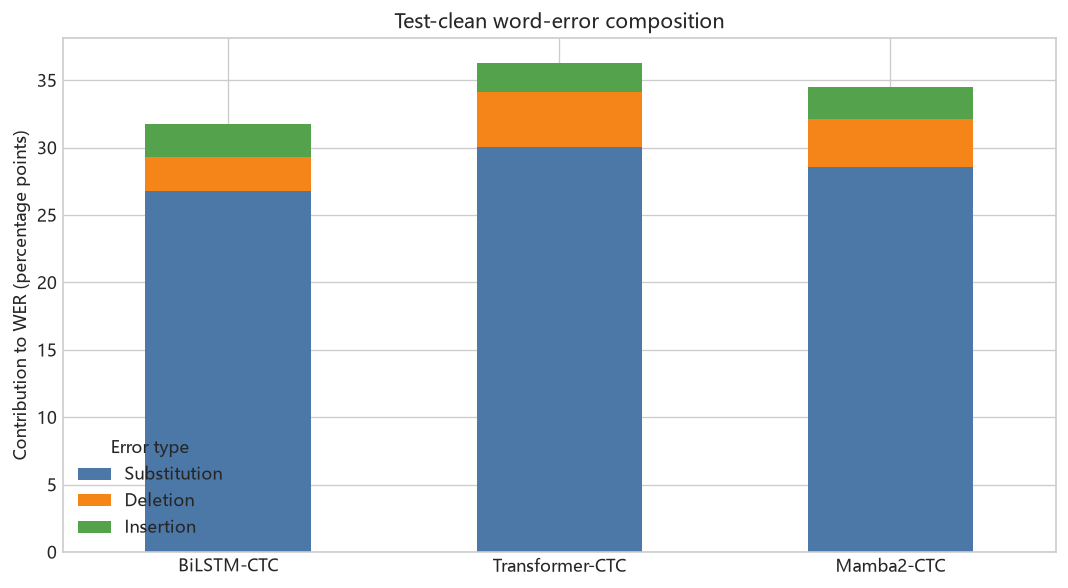

,Substitution,Deletion,Insertion
Model,,,
BiLSTM-CTC,26.80,2.51,2.46
Transformer-CTC,30.07,4.01,2.21
Mamba2-CTC,28.55,3.57,2.40


In [11]:
error_rows = []
for model, group in prediction_details.groupby("Model", sort=False):
    ref_words = group["reference_words"].sum()
    error_rows.append(
        {
            "Model": model,
            "Substitution": 100 * group["substitutions"].sum() / ref_words,
            "Deletion": 100 * group["deletions"].sum() / ref_words,
            "Insertion": 100 * group["insertions"].sum() / ref_words,
        }
    )

error_df = pd.DataFrame(error_rows).set_index("Model")
fig, ax = plt.subplots(figsize=(9, 5))
error_df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#4C78A8", "#F58518", "#54A24B"],
)
ax.set_ylabel("Contribution to WER (percentage points)")
ax.set_xlabel("")
ax.set_title("Test-clean word-error composition")
ax.legend(title="Error type")
ax.tick_params(axis="x", rotation=0)

save_and_show(fig, "test_error_composition.png")
display(error_df.style.format("{:.2f}"))

## 10. 语句长度对 WER 的影响

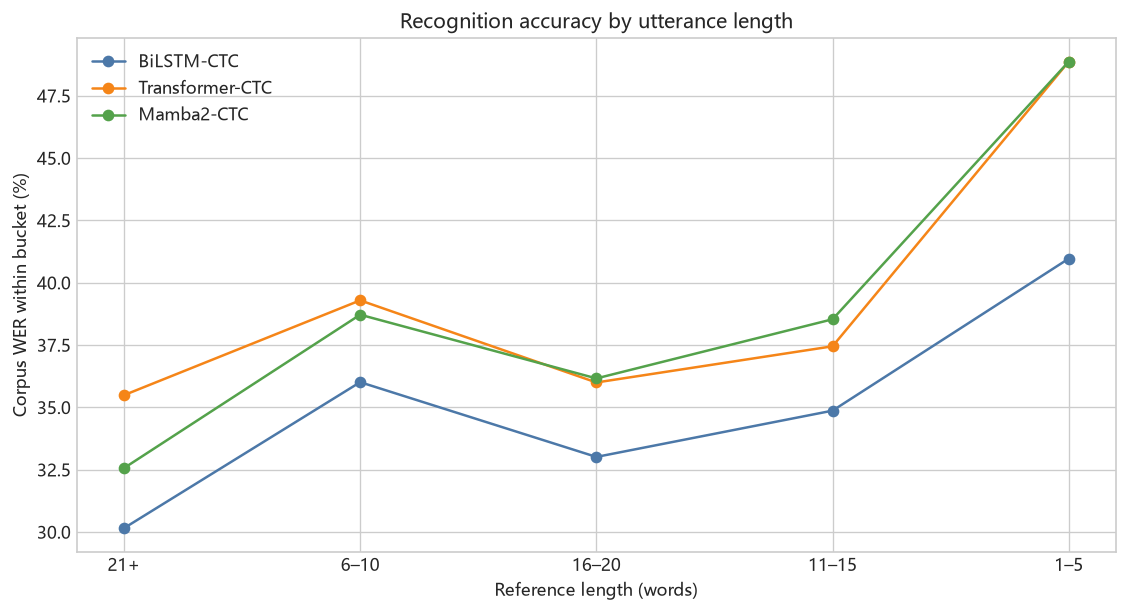

Model,BiLSTM-CTC,Mamba2-CTC,Transformer-CTC
Length group,,,
11–15,34.87,38.53,37.45
16–20,33.01,36.16,36.00
1–5,40.97,48.87,48.87
21+,30.15,32.56,35.49
6–10,36.01,38.72,39.29


In [12]:
length_bins = [0, 5, 10, 15, 20, np.inf]
length_labels = ["1–5", "6–10", "11–15", "16–20", "21+"]
prediction_details["Length group"] = pd.cut(
    prediction_details["reference_words"],
    bins=length_bins,
    labels=length_labels,
    include_lowest=True,
)

bucket_rows = []
for (model, length_group), group in prediction_details.groupby(
    ["Model", "Length group"], observed=False, sort=False
):
    bucket_rows.append(
        {
            "Model": model,
            "Length group": length_group,
            "WER (%)": 100 * group["word_errors"].sum() / group["reference_words"].sum(),
            "Utterances": len(group),
        }
    )

bucket_df = pd.DataFrame(bucket_rows)
fig, ax = plt.subplots(figsize=(9.5, 5.2))
for model in MODEL_RUNS:
    subset = bucket_df[bucket_df["Model"] == model]
    ax.plot(
        subset["Length group"].astype(str),
        subset["WER (%)"],
        marker="o",
        label=model,
        color=COLORS[model],
    )

ax.set_xlabel("Reference length (words)")
ax.set_ylabel("Corpus WER within bucket (%)")
ax.set_title("Recognition accuracy by utterance length")
ax.legend()

save_and_show(fig, "wer_by_utterance_length.png")
display(bucket_df.pivot(index="Length group", columns="Model", values="WER (%)").style.format("{:.2f}"))

## 11. 典型困难样例

In [13]:
reference_frame = predictions["BiLSTM-CTC"][["utterance_id", "reference"]].copy()
hypothesis_wide = prediction_details.pivot(
    index="utterance_id", columns="Model", values="hypothesis"
).reset_index()
errors_wide = prediction_details.pivot(
    index="utterance_id", columns="Model", values="word_errors"
)

hard_ids = errors_wide.mean(axis=1).sort_values(ascending=False).head(10).index
hard_examples = (
    reference_frame[reference_frame["utterance_id"].isin(hard_ids)]
    .merge(hypothesis_wide, on="utterance_id", how="left")
    .set_index("utterance_id")
    .loc[hard_ids]
)
hard_examples.to_csv(OUTPUT_DIR / "hard_examples.tsv", sep="	")
display(hard_examples.style.set_properties(**{"text-align": "left", "white-space": "normal"}))

,reference,BiLSTM-CTC,Mamba2-CTC,Transformer-CTC
utterance_id,,,,
3570-5696-0003,A RECONCILIATION BETWEEN THE TWO CONFLICTING REQUIREMENTS IS EFFECTED BY A RESORT TO MAKE BELIEVE MANY AND INTRICATE POLITE OBSERVANCES AND SOCIAL DUTIES OF A CEREMONIAL NATURE ARE DEVELOPED MANY ORGANIZATIONS ARE FOUNDED WITH SOME SPECIOUS OBJECT OF AMELIORATION EMBODIED IN THEIR OFFICIAL STYLE AND TITLE THERE IS MUCH COMING AND GOING AND A DEAL OF TALK TO THE END THAT THE TALKERS MAY NOT HAVE OCCASION TO REFLECT ON WHAT IS THE EFFECTUAL ECONOMIC VALUE OF THEIR TRAFFIC,AR RECONCILIATION BTWEEN THE TWO COMFEC THING WOLD GLIMANTS IS AFECTED BY RESORT TO MAKE BELIEVE MENAN INTOUCKOD POLICT OF SEVENSES AND SOCIAL TUUTIS OF A CRMONIA NATURE ORE DEVELOPED MAN ORGANIZATION SUF HOUNDED WITH SOME SPECIOUS UBJICT OF IMELIERATION EMBULDED IN THEIR OFFICIAL STION TIGTLE THERE IS MUCH COMING AND GOING AND A DEAL OF TALK TO TDEAM THAT THE TALK AS MAYE OT CAVICATION TO REFECT ON WHOATE IS THE EFFECTUIAL ECONOMIC VALLY OF THAIR CRAFIC,A RECONSILIATION TWN THE WO CONFECT ANGLIT UIMENCS IS IFFCTED BY RESORT TO MAKE BELIEVE MIN IND INTRICATE POLITE ABSERVANCESMND SOCIAL DUTICSO ICEROMONIAN NATURE ORGIVELOPED MANY ARGANIZATION SUF HOUND WITH SOME SPECIOUS OBJECT OF IMMILIARATION AMD BULDED IN THEIR OFFICIAL STYLUNTITHTLE THERE ISMUCH COMING AND GOING AND A DEALOF TOLK TO THE END T AT TH TOLKE'S AYNOT HAVEOCATION TO REFECT ON WORT IS HE EFFECTCHAL CONOMIC VALUE OF THER TRAFC,AI RECONSILATION ETEE THE TWO CONFEICTHING WRE ULIMENTS IS EFFECTED BY RESORTED TO MAKE BELIEVE MEN AIN INTRICOULD POLITE OBSERVAN SOS SEN SOIAL DUEIS F A CERMONIN NATURE I GEVELOPED MANRCANIZATION SUFOUND WITH SOME SPECIUS OBJECT OF AMULIRATION AN BUTED IN THEIR OFFIAL STYLENTIEL THERIS METH COMNG NGOLAN THND E DELOF THOLKCK T THE AN TH THTOCEHI MAN OLTAVFE CATION T RE RECTCONWOT HISTHE FFECTUAL COM MC VALE O TEIRKTREFIC
5142-36377-0014,A PRETTY GIRL AND SO FAR AS I COULD JUDGE BY APPEARANCES A GOOD GIRL TOO DESCRIBING HER GENERALLY I MAY SAY THAT SHE HAD A SMALL HEAD WELL CARRIED AND WELL SET ON HER SHOULDERS BRIGHT GRAY EYES THAT LOOKED AT YOU HONESTLY AND MEANT WHAT THEY LOOKED A TRIM SLIGHT LITTLE FIGURE TOO SLIGHT FOR OUR ENGLISH NOTIONS OF BEAUTY A STRONG AMERICAN ACCENT AND A RARE THING IN AMERICA A PLEASANTLY TONED VOICE WHICH MADE THE ACCENT AGREEABLE TO ENGLISH EARS,A PRETTY GIRL MANE AFARS I CULD JUC BY APEANCES A GOOD GIRL TOO DESCRIBING MER GERINLY ID MAY SAY THET SHED A SMALL HEAD WELL CARRIED AND WELL SETERGOR SOULDERS FOR I GRAY EYES THATLOOKED YOU HONESTLY AND MENT WHAT THEYLOOKED A TRIM SLIGHT LITTLE THIYGYEST TO SLIGHT FOR OUR ENGLISH NOTIONS OF BEAUTY A STRONG AMERICAN ACNONT AND A RATHING INAMERICA A PLEASATLY TONE VOICE WHICH MADE THE ACCINENT AGREEABLE TO ENGLISH YEARS,A PRETTY GIRL MONH I FARS LIK OALDJUGE BY APARANCES A GOOD GIRL TOO DESCRIVBING HER GENERALLY I MAY SAY THE SHE HAD A SMALL HEAD WELL CARRIED IN WLL SEVENORSHOULDERS FOR I GRAY EYES THAT LOOKED O OU HONSTLY AND MENT WITH A LOOKED A TRIM SLIGHT LITE THEY GIVE TOO SLIGHT FR OR ENLISH NOTIONS OF IEAUTY A STRONG AMERICAN ACINENT AND ARAF AND AN AMERICA A PLEASANTLY TONE VOICE WHICH MAE THE ACCIAENT A GREEALE TO ENGLISHYEARS,A PRETTY GIR OLMEN IFHARS I COULJUDGTD BY A PARANCES A GOOD CIRL TOO DESCRIBING HERGENEALLY I MAY SAY THE SHEAD A SMALL HEAD WELL CARRYE AND WELL SET N RE SHOULDERS FOR IGHT GREY E THAT LOOKE AT YOUHONESTLY ENMENT WITH THE LOOED A TRIMSLIHT LITLE HIGES TIS LIGHT FOAR ENGLISH NOCIONSFEAUTY AS TROMEICONACK S NAONT ANNT A RAI HNGNIMERICA A PLESELYTON VOI HICH MAYDTY ACESENT A GREEABLE TA ENGLISHIER
1995-1836-0004,AS SHE AWAITED HER GUESTS SHE SURVEYED THE TABLE WITH BOTH SATISFACTION AND DISQUIETUDE FOR HER SOCIAL FUNCTIONS WERE FEW TONIGHT THERE WERE SHE CHECKED THEM OFF ON HER FINGERS SIR JAMES CREIGHTON THE RICH ENGLISH MANUFACTURER AND LADY CREIGHTON MISTER AND MISSUS VANDERPOOL MISTER HARRY CRESSWELL AND HIS SISTER JOHN TAYLOR AND HIS SISTER AND MISTER CHARLES SMITH WHOM THE EVENING PAPERS 

## 12. 自动生成的核心结论

以下结论由当前下载的记录动态生成；重新训练或替换 `runs` 后，重新运行 Notebook 即可更新。

In [14]:
best_wer_model = evaluation_df["Test WER (%)"].idxmin()
best_cer_model = evaluation_df["Test CER (%)"].idxmin()
fastest_epoch_model = training_df["Mean epoch time (s)"].idxmin()
shortest_convergence_model = training_df["Best epoch"].idxmin()
lowest_total_time_model = training_df["Total train time (h)"].idxmin()

conclusions = f'''
### 当前实验结论

- **Test WER 最低**：{best_wer_model}，{evaluation_df.loc[best_wer_model, 'Test WER (%)']:.2f}%。
- **Test CER 最低**：{best_cer_model}，{evaluation_df.loc[best_cer_model, 'Test CER (%)']:.2f}%。
- **平均单轮速度最快**：{fastest_epoch_model}，{training_df.loc[fastest_epoch_model, 'Mean epoch time (s)']:.1f} 秒/轮。
- **最佳 checkpoint 出现最早**：{shortest_convergence_model}，第 {int(training_df.loc[shortest_convergence_model, 'Best epoch'])} 轮。
- **记录到的总训练时间最低**：{lowest_total_time_model}，{training_df.loc[lowest_total_time_model, 'Total train time (h)']:.2f} 小时。
- 三个模型均在同一 `test-clean` 集合的 2,620 条语音上评估，比较口径一致。

### 写报告时需要保留的限制

- 当前每种结构只有 **seed=7 的单次实验**，不能据此声称差异具有统计显著性；建议后续增加多个 seed 并报告均值和标准差。
- 所有结果使用 **CTC greedy decoding**，没有外部语言模型；结论反映的是声学模型加贪心解码的表现。
- GPU CTC backward 会产生“无完全确定性实现”的警告，因此即使固定 seed，也可能存在极小的浮点差异。
- 三种模型的停止轮次不同，应同时比较准确率、参数量、总训练时间和单轮速度，而不能只比较最后一轮 loss。
'''
display(Markdown(conclusions))


### 当前实验结论

- **Test WER 最低**：BiLSTM-CTC，31.77%。
- **Test CER 最低**：BiLSTM-CTC，11.63%。
- **平均单轮速度最快**：Transformer-CTC，86.7 秒/轮。
- **最佳 checkpoint 出现最早**：Mamba2-CTC，第 33 轮。
- **记录到的总训练时间最低**：Mamba2-CTC，1.65 小时。
- 三个模型均在同一 `test-clean` 集合的 2,620 条语音上评估，比较口径一致。

### 写报告时需要保留的限制

- 当前每种结构只有 **seed=7 的单次实验**，不能据此声称差异具有统计显著性；建议后续增加多个 seed 并报告均值和标准差。
- 所有结果使用 **CTC greedy decoding**，没有外部语言模型；结论反映的是声学模型加贪心解码的表现。
- GPU CTC backward 会产生“无完全确定性实现”的警告，因此即使固定 seed，也可能存在极小的浮点差异。
- 三种模型的停止轮次不同，应同时比较准确率、参数量、总训练时间和单轮速度，而不能只比较最后一轮 loss。


## 输出文件

运行完成后，`analysis_outputs/` 中会得到可直接插入报告的 PNG 图和 CSV/TSV 汇总表：

- `training_loss_curves.png`
- `dev_error_curves.png`
- `optimization_diagnostics.png`
- `test_metrics.png`
- `efficiency_tradeoff.png`
- `test_error_composition.png`
- `wer_by_utterance_length.png`
- `training_comparison.csv`
- `evaluation_comparison.csv`
- `prediction_level_metrics.csv`
- `hard_examples.tsv`